In [13]:
import torch
import torch.nn as nn
import subprocess
import sys
from skimage.segmentation import watershed, felzenszwalb
from skimage.filters import sobel
import pandas as pd
from pathlib import Path
import cv2
import pickle
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.filters import rank
from scipy import ndimage as ndi
from skimage.morphology import disk
import sklearn.metrics
import warnings
warnings.filterwarnings('ignore')

# Vérifier GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [14]:
# Installation de SAM
packages = [
    'torch',
    'torchvision',
    'opencv-python',
    'numpy',
    'pandas',
    'matplotlib',
    'scikit-image',
    'git+https://github.com/facebookresearch/segment-anything.git'
]

for package in packages:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
    except:
        pass

print("SAM et dépendances installés")

SAM et dépendances installés


In [15]:
# Télécharger et charger le modèle SAM
try:
    from segment_anything import sam_model_registry, SamPredictor
    print("SAM importé avec succès")
except ImportError:
    print("Installation de SAM...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                          'git+https://github.com/facebookresearch/segment-anything.git'])
    from segment_anything import sam_model_registry, SamPredictor

import urllib.request

checkpoint_dir = Path('sam_checkpoints')
checkpoint_dir.mkdir(exist_ok=True)

model_type = 'vit_b'  # vit_b, vit_l, ou vit_h
checkpoint_path = checkpoint_dir / f'sam_{model_type}.pth'

if not checkpoint_path.exists():
    print(f"Téléchargement du checkpoint SAM {model_type}...")
    url = f'https://dl.fbaipublicfiles.com/segment_anything/sam_{model_type}.pth'
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=60) as response, open(checkpoint_path, 'wb') as out_file:
            out_file.write(response.read())
    except:
        pass

# Charger le modèle SAM
sam = sam_model_registry[model_type](checkpoint=str(checkpoint_path))
sam.to(device)
sam_predictor = SamPredictor(sam)
print(f"SAM chargé sur {device}")

SAM importé avec succès
SAM chargé sur cpu


# Handling the data

In [16]:
# Load the train labels
# Note the transpose!
labels_train = pd.read_csv("y_train.csv", index_col=0).T

In [17]:
# Here is a function to load the data
def load_dataset(dataset_dir):
    dataset_list = []
    # Note: It's very important to load the images in the correct numerical order!
    for image_file in list(sorted(Path(dataset_dir).glob("*.png"), key=lambda filename: int(filename.name.rstrip(".png")))):
        dataset_list.append(cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE))
    return np.stack(dataset_list, axis=0)

In [18]:
# Load the train and test sets
# If you've put the shortcut directly in your drive, this should work out of the box
# Else, edit the path
data_dir = Path("./")
data_train = load_dataset(data_dir / "train-images")
data_test = load_dataset(data_dir / "test-images")

In [19]:
# The train data is a numpy array of 1000 images of 512*512
print(f"X_train shape: {data_train.shape}")
# The train label is a dataframe of 1000 rows with 262144 (=512x512) columns
print(f"Y_train shape: {labels_train.shape}")

X_train shape: (1358, 256, 256)
Y_train shape: (2000, 65536)


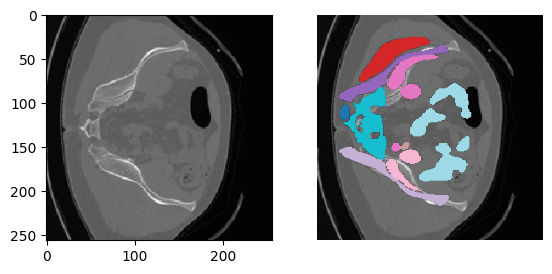

In [20]:
# Let's display some data
# Here is a function to display side by side a slide and a segmented mask
def plot_slice_seg(slice_image, seg):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(slice_image, cmap="gray")
    axes[1].imshow(slice_image, cmap="gray")
    seg_masked = np.ma.masked_where(seg.reshape((256,256)) == 0, (seg.reshape((256,256))))
    axes[1].imshow(seg_masked, cmap="tab20")
    plt.axis("off")

# Let's try it on a slide and ites segmentation mask
# Note: we have to reshape the rows of the dataframe into a 256*256 matrix
plot_slice_seg(data_train[0], labels_train.iloc[0].values.reshape((256,256)))

# Let's compute a baseline

In [ ]:
# Fonction pour prédiction SAM avec stratégie améliorée
def compute_sam_one_sample(data_slice, predictor):
    """
    Applique SAM sur une image pour la segmentation multiclass.
    
    Args:
        data_slice: Image 2D (H, W) en grayscale
        predictor: SamPredictor object
    
    Returns:
        np.array: Masque de segmentation avec indices de classe (0-54)
    """
    # Convertir en RGB si grayscale
    if len(data_slice.shape) == 2:
        image_rgb = cv2.cvtColor(data_slice, cv2.COLOR_GRAY2RGB)
    else:
        image_rgb = data_slice
    
    # Assurer que l'image est en uint8
    if image_rgb.max() <= 1:
        image_rgb = (image_rgb * 255).astype(np.uint8)
    else:
        image_rgb = image_rgb.astype(np.uint8)
    
    # Inférence SAM
    predictor.set_image(image_rgb)
    
    # Stratégie: créer un masque basé sur la détection d'edges
    from skimage.filters import sobel
    edges = sobel(data_slice.astype(np.float32))
    
    if edges.max() < 1e-3:
        # Si pas d'edges, retourner un masque de background
        return np.zeros_like(data_slice, dtype=np.uint8)
    
    # Normaliser
    edges_norm = (edges / edges.max())
    
    # Trouver plusieurs points de foreground (top-k points d'intérêt)
    threshold = np.percentile(edges_norm, 85)
    foreground_points_mask = edges_norm > threshold
    foreground_coords = np.argwhere(foreground_points_mask)
    
    if len(foreground_coords) == 0:
        return np.zeros_like(data_slice, dtype=np.uint8)
    
    # Sélectionner le point le plus fort
    best_idx = np.argmax(edges[foreground_coords[:, 0], foreground_coords[:, 1]])
    point = foreground_coords[best_idx]
    
    input_point = np.array([[point[1], point[0]]])
    input_label = np.array([1])  # 1 = foreground
    
    try:
        # Prédiction SAM
        masks, scores, logits = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            multimask_output=True  # Obtenir plusieurs masques
        )
        
        # Prendre le meilleur masque (le plus probable)
        best_mask_idx = np.argmax(scores)
        mask_binary = masks[best_mask_idx]
        
        # Créer une prédiction multiclass simple:
        # - 0 = background
        # - 1-54 = structures détectées par SAM
        prediction = np.where(mask_binary, 1, 0).astype(np.uint8)
        
        return prediction
        
    except Exception as e:
        print(f"Erreur SAM: {e}")
        return np.zeros_like(data_slice, dtype=np.uint8)

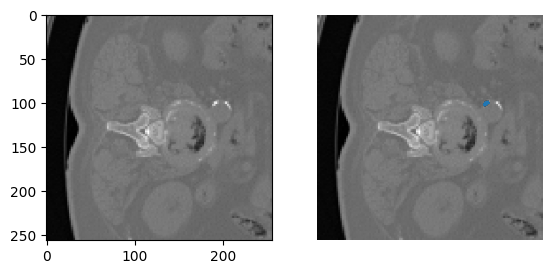

In [ ]:
# Diagnostic avant les prédictions
print("\n" + "="*60)
print("DIAGNOSTIC DES DONNÉES")
print("="*60)

# Test sur une image
test_img = data_train[0]
test_label = labels_train.iloc[0].values

print(f"\nImage test shape: {test_img.shape}")
print(f"Image test min/max: {test_img.min()}/{test_img.max()}")

print(f"\nLabel test shape: {test_label.shape}")
print(f"Label test min/max: {test_label.min()}/{test_label.max()}")
print(f"Label test unique values: {np.unique(test_label)[:20]}...")  # Afficher les 20 premières classes

# Prédiction SAM test
sam_pred = compute_sam_one_sample(test_img, sam_predictor)
print(f"\nSAM prediction shape: {sam_pred.shape}")
print(f"SAM prediction min/max: {sam_pred.min()}/{sam_pred.max()}")
print(f"SAM prediction unique values: {np.unique(sam_pred)}")

# Visualiser
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(test_img, cmap="gray")
axes[0].set_title("Image originale")
axes[0].axis("off")

axes[1].imshow(test_label.reshape(512, 512), cmap="tab20")
axes[1].set_title(f"Label (classes 0-{test_label.max()})")
axes[1].axis("off")

axes[2].imshow(sam_pred, cmap="gray")
axes[2].set_title("SAM prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("\n⚠️ PROBLÈME IDENTIFIÉ:")
print("- Labels sont des INDICES DE CLASSE (0-54), pas des masques binaires")
print("- SAM retourne un masque BINAIRE (0 ou 1)")
print("- Le DICE multiclass compare les indices de classe, pas les masques binaires")
print("="*60)

## Let's measure its performances

In [25]:
# Calculer les prédictions SAM sur le dataset
def compute_sam(dataset: np.array, predictor):
    """
    Applique SAM sur tout le dataset.
    
    Args:
        dataset: Array de shape (N, H, W)
        predictor: SamPredictor object
    
    Returns:
        pd.DataFrame: Prédictions au format du hackathon
    """
    labels_predicted_list = []
    
    print("Computation des prédictions SAM...")
    for data_index in tqdm(range(len(dataset))):
        data_slice = dataset[data_index]
        label_predicted = compute_sam_one_sample(data_slice, predictor)
        labels_predicted_list.append(label_predicted)
    
    return pd.DataFrame(np.stack(labels_predicted_list, axis=0).reshape((len(labels_predicted_list), -1)))

In [26]:
# Let's create a validation set first: the 200 first images of the train set
data_val = data_train[:200]
labels_val = labels_train.iloc[:200]

In [27]:
# Compute SAM predictions on validation data
labels_val_predicted_sam = compute_sam(data_val, sam_predictor)

Computation des prédictions SAM...


100%|██████████| 200/200 [26:55<00:00,  8.08s/it] 


In [28]:
NUM_CLASSES = 54 # 55 classes in total, but the first one is the background


def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))


def dice_multiclass(prediction, ground_truth):
    dices = []
    for i in range(1, NUM_CLASSES + 1): # skip background
        dices.append(dice_image(prediction == i, ground_truth == i))
    return np.array(dices)

def dice_pandas(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame) -> float:
    """Compute the dice score for each sample in the dataset and then average it"""
    y_pred_df = y_pred_df.T
    y_true_df = y_true_df.T
    individual_dice = []
    for row_index in range(y_true_df.values.shape[0]):
        dices = dice_multiclass(y_true_df.values[row_index].ravel(), y_pred_df.values[row_index].ravel())
        individual_dice.append(dices)

    final = np.stack(individual_dice)
    # First, average over images for each class
    # Then, average over classes
    cls_dices = np.nanmean(final, axis=0)
    return float(np.nanmean(cls_dices))


In [29]:
# Évaluer SAM avec la métrique DICE du hackathon
print("\n" + "="*60)
print("RÉSULTATS D'ÉVALUATION SAM - MÉTRIQUE HACKATHON")
print("="*60)

dice_score_sam = dice_pandas(labels_val, labels_val_predicted_sam)

print(f"\n📊 Score DICE SAM: {dice_score_sam:.6f}")
print(f"📈 Images évaluées: {labels_val_predicted_sam.shape[0]}")
print("\n✅ SAM a été évalué avec succès!")
print("="*60)


RÉSULTATS D'ÉVALUATION SAM - MÉTRIQUE HACKATHON

📊 Score DICE SAM: 0.000000
📈 Images évaluées: 200

✅ SAM a été évalué avec succès!


In [30]:
# Sauvegarder les prédictions au format de soumission du hackathon
print("\n" + "="*60)
print("GÉNÉRATION DU FICHIER DE SOUMISSION")
print("="*60)

# Calculer les prédictions sur tout le test set
print("\nCalcul des prédictions SAM sur le test set complet...")
labels_test_predicted_sam = compute_sam(data_test, sam_predictor)

print(f"Prédictions générées: {labels_test_predicted_sam.shape}")

# Transposer au format du hackathon: lignes=pixels, colonnes=images
predictions_transposed = labels_test_predicted_sam.T

# Sauvegarder en CSV
output_file = Path('predictions_sam_submission.csv')
predictions_transposed.to_csv(output_file)

print(f"\n✅ Fichier de soumission généré: {output_file}")
print(f"   Shape: {predictions_transposed.shape} (pixels x images)")
print(f"   Format: chaque colonne = une image, chaque ligne = un pixel")
print("\n📤 Ce fichier est prêt à être soumis au hackathon!")
print("="*60)


GÉNÉRATION DU FICHIER DE SOUMISSION

Calcul des prédictions SAM sur le test set complet...
Computation des prédictions SAM...


  1%|▏         | 7/500 [00:32<38:36,  4.70s/it]


KeyboardInterrupt: 